Insertion sort vs Merge sort vs Quick sort on SMALL lists. We will show specific cases where Insertion sort does better than the other two, as well as cases where it is most definitely worse.

In [ ]:
from auxilary.bad_sorts import create_random_list, create_near_sorted_list, insertion_sort
from auxilary.good_sorts import mergesort, quicksort
import matplotlib.pyplot as plt
from collections import defaultdict
import timeit
import gc

In [21]:
def random_reverse_sorted_list(max_value):
    return list(range(max_value, 0, -1))

# we use this function to check insertion sort's best case
def count_inversions(L):
    # An inversion is a pair of indices (i, j) such that i < j but L[i] > L[j].
    # This directly correlates to how many "swaps" insertion sort must do.
    count = 0
    n = len(L)
    for i in range(n):
        for j in range(i + 1, n):
            if L[i] > L[j]:
                count += 1
    return count

# sort the information we get from counting out of place 
def sort_results(x_vals, y_vals):
    zipped = sorted(zip(x_vals, y_vals))
    x_sorted, y_sorted = zip(*zipped)
    return list(x_sorted), list(y_sorted)

# bin data to smooth spikes 
def bin_data(raw_data, bin_size=25):
    bins = defaultdict(list)
    for inv, time in raw_data:
        # Round to nearest multiple of bin_size (e.g., 0, 25, 50, 75...)
        bucket = bin_size * round(inv / bin_size)
        bins[bucket].append(time)
    
    # Calculate average for each bin
    x_vals = []
    y_vals = []
    for bucket in sorted(bins.keys()):
        avg_time = sum(bins[bucket]) / len(bins[bucket])
        x_vals.append(bucket)
        y_vals.append(avg_time)
        
    return x_vals, y_vals


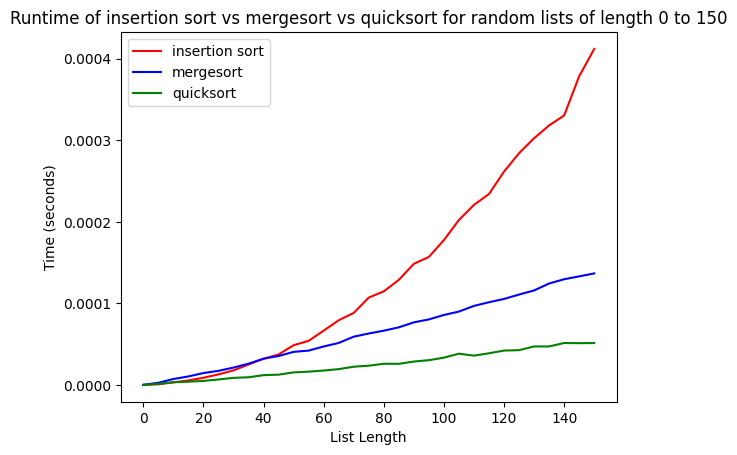

In [39]:
# intiialise lists of fixed lengths for now
# Create a list of lengths from 0 - 150 stepping by 3
lengths = list(range(0, 150, 1))
lists = [create_random_list(l, 10000) for l in lengths]
default_bin_size = 5

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []
# tests per list, take the best occurence
trials = 500
for i in range(n):
    
    best = float('inf')
    gc.disable()
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append((i, best))
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append((i, best))
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append((i, best))
    gc.enable()

x_ins, y_ins = bin_data(insertion_times, bin_size=default_bin_size)
x_merge, y_merge = bin_data(mergesort_times, bin_size=default_bin_size)
x_quick, y_quick = bin_data(quicksort_times, bin_size=default_bin_size)

plt.plot(x_ins, y_ins, color='red')
plt.plot(x_merge, y_merge, color='blue')
plt.plot(x_quick, y_quick, color='green')
plt.legend(['insertion sort', 'mergesort', 'quicksort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of insertion sort vs mergesort vs quicksort for random lists of length 0 to 150')
plt.show()

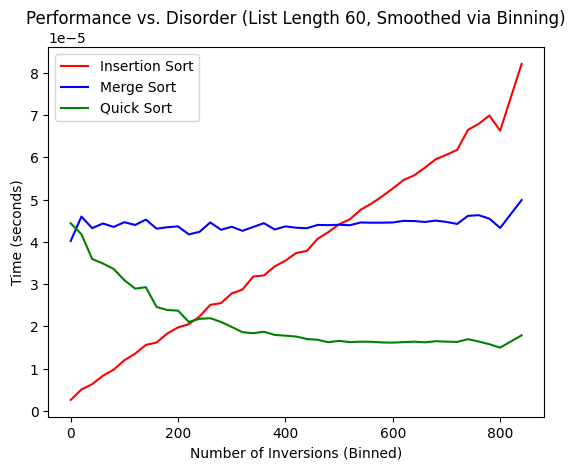

In [ ]:
max_length = 50
swaps_config = list(range(0, 200, 2))
trials_per_list = 20 
lists_per_swap = 50 # importan 
default_bin_size = 25

# We store tuples: (inversion_count, time)
raw_data_ins = []
raw_data_merge = []
raw_data_quick = []

for s in swaps_config:
    # Generate 5-10 lists per swap count to get a spread of inversions
    for _ in range(lists_per_swap): 
        current_list = create_near_sorted_list(max_length, 5000, s)
        real_inversions = count_inversions(current_list)
        
        gc.disable()
        best = float('inf')
        for _ in range(trials_per_list):
            l_copy = current_list[:]
            start = timeit.default_timer()
            insertion_sort(l_copy)
            elapsed = timeit.default_timer() - start
            best = min(best, elapsed)
        gc.enable()
        raw_data_ins.append((real_inversions, best))

        gc.disable()
        best = float('inf')
        for _ in range(trials_per_list):
            l_copy = current_list[:]
            start = timeit.default_timer()
            mergesort(l_copy)
            elapsed = timeit.default_timer() - start
            best = min(best, elapsed)
        gc.enable()
        raw_data_merge.append((real_inversions, best))
        
        gc.disable()
        best = float('inf')
        for _ in range(trials_per_list):
            l_copy = current_list[:]
            start = timeit.default_timer()
            quicksort(l_copy)
            elapsed = timeit.default_timer() - start
            best = min(best, elapsed)
        gc.enable()
        raw_data_quick.append((real_inversions, best))



# Bin size of 20-30 
x_ins, y_ins = bin_data(raw_data_ins, bin_size=default_bin_size)
x_merge, y_merge = bin_data(raw_data_merge, bin_size=default_bin_size)
x_quick, y_quick = bin_data(raw_data_quick, bin_size=default_bin_size)

plt.plot(x_ins, y_ins, color='red', label='Insertion Sort')
plt.plot(x_merge, y_merge, color='blue', label='Merge Sort')
plt.plot(x_quick, y_quick, color='green', label='Quick Sort')

plt.legend()
plt.xlabel('Number of Inversions (Binned)')
plt.ylabel('Time (seconds)')
plt.title('Performance vs. Disorder (List Length 60, Smoothed via Binning)')
plt.show()

In [ ]:
# random reversed lists only
lengths = list(range(0, 60, 1))
lists = [random_reverse_sorted_list(l) for l in lengths]

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []
# tests per list, take the best occurence
trials = 5000
for i in range(n):
    
    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append(best)
    gc.enable()
    

plt.plot(lengths, insertion_times, color='red')
plt.plot(lengths, mergesort_times, color='blue')
plt.plot(lengths, quicksort_times, color='green')
plt.legend(['insertion sort', 'mergesort', 'quicksort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of insertion sort vs mergesort vs quicksort for reverse sorted lists of length 0 to 60')
plt.show()

In [63]:
lengths = list(range(10, 200, 10)) 
ratios = []

print("Analyzing inversion ratios...")

for l_len in lengths:
    trials = 5
    trial_ratios = []
    
    for _ in range(trials):
        lst = create_random_list(l_len, 10000)
        
        real_inv = count_inversions(lst)
        
        # Calculate Max Possible Inversions for this length: N * (N-1) / 2
        max_possible_inv = l_len * (l_len - 1) / 2
        
        if max_possible_inv > 0:
            trial_ratios.append(real_inv / max_possible_inv)
            
    # Average for this length
    ratios.append(sum(trial_ratios) / len(trial_ratios))

# Final global average
average_ratio = sum(ratios) / len(ratios)

print(f"Average Inversion Ratio (Actual / Max Possible): {average_ratio:.4f}")
print("Interpretation: A random list typically contains ~50% of the maximum possible inversions.")

Analyzing inversion ratios...
Average Inversion Ratio (Actual / Max Possible): 0.5038
Interpretation: A random list typically contains ~50% of the maximum possible inversions.
